# تحلیل کامل دیتاست عیب ورق فولادی

این نوت‌بوک کل روند تحلیل‌گر را از ریشه پروژه اجرا می‌کند و هر سه مرحله را به‌صورت واقعی اجرا می‌کند. داده خام بدون تغییر حفظ شده است؛ تمام تصمیم‌های انتخاب با Train/CV انجام می‌شوند و Test فقط برای ارزیابی نهایی است.


In [1]:
from pathlib import Path
import sys, json, pandas as pd
ROOT=Path.cwd()
if not (ROOT/"data/raw/Faults.NNA").exists(): ROOT=Path("..").resolve()
sys.path.insert(0,str(ROOT/"src"))
print(ROOT)

/mnt/data/audit2/unzip/data-analysis_project4


## ۱. اعتبارسنجی داده خام

In [2]:
from data_loader import load_raw
from preprocessing import validate_one_hot
df, features, targets = load_raw(ROOT)
print("shape:", df.shape)
print("features:", len(features), "targets:", len(targets))
print("missing:", int(df.isna().sum().sum()))
print("duplicates:", int(df.duplicated().sum()))
print(validate_one_hot(df, targets))
assert df.shape==(1941,34) and len(features)==27 and len(targets)==7

shape: (1941, 34)
features: 27 targets: 7
missing: 0
duplicates: 0
{'valid': True, 'zero_label_rows': 0, 'multi_label_rows': 0, 'total_rows': 1941}


## ۲. اجرای مرحله اول

In [3]:
import runpy
runpy.run_path(str(ROOT/'src/eda_stage1.py'), run_name='__main__')


{
  "rows": 1941,
  "feature_count": 27,
  "target_count": 7,
  "missing_values": 0,
  "duplicate_rows": 0,
  "onehot_invalid_rows": 0,
  "classes": [
    "Pastry",
    "Z_Scratch",
    "K_Scatch",
    "Stains",
    "Dirtiness",
    "Bumps",
    "Other_Faults"
  ],
  "class_counts": {
    "Pastry": 158,
    "Z_Scratch": 190,
    "K_Scatch": 391,
    "Stains": 72,
    "Dirtiness": 55,
    "Bumps": 402,
    "Other_Faults": 673
  }
}


{'__name__': '__main__',
 '__doc__': None,
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/mnt/data/audit2/unzip/data-analysis_project4/src/eda_stage1.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <function __build_class__>,
  '__import__': <function __import__(name, globals=None, locals=Non

## ۳. اجرای مرحله دوم

In [4]:
import runpy
runpy.run_path(str(ROOT/'src/stage2_analysis.py'), run_name='__main__')


{
  "train_n": 1358,
  "validation_n": 291,
  "test_n": 292,
  "iqr_global_flagged_rows": 582,
  "iqr_global_flagged_pct": 42.857142857142854,
  "isolation_global_flagged_rows": 68,
  "isolation_global_flagged_pct": 5.007363770250368,
  "both_global_methods_flagged_rows": 68,
  "top_iqr_features": {
    "Sum_of_Luminosity": 283,
    "Pixels_Areas": 275,
    "Outside_X_Index": 266,
    "X_Perimeter": 243,
    "Steel_Plate_Thickness": 166,
    "Y_Perimeter": 131,
    "Maximum_of_Luminosity": 106,
    "Luminosity_Index": 102,
    "Y_Minimum": 62,
    "Y_Maximum": 62
  },
  "high_corr_pairs": 20
}
SPLIT 1358 291 292
RED        feature_1         feature_2  correlation  abs_correlation redundancy_flag
TypeOfSteel_A300  TypeOfSteel_A400    -1.000000         1.000000            high
       Y_Minimum         Y_Maximum     1.000000         1.000000            high
    Pixels_Areas Sum_of_Luminosity     0.996438         0.996438            high
       X_Minimum         X_Maximum     0.987051     

{'__name__': '__main__',
 '__doc__': None,
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/mnt/data/audit2/unzip/data-analysis_project4/src/stage2_analysis.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <function __build_class__>,
  '__import__': <function __import__(name, globals=None, local

## ۴. اجرای مرحله سوم

In [5]:
import runpy
_ = runpy.run_path(str(ROOT/'src/stage3_analysis.py'), run_name='__main__')


## ۵. خروجی‌های کلیدی

Final artifact checks:


processed: (1941, 29)
classes:
       class  count  percentage
      Pastry    158    8.140134
   Z_Scratch    190    9.788769
    K_Scatch    391   20.144256
      Stains     72    3.709428
   Dirtiness     55    2.833591
       Bumps    402   20.710974
Other_Faults    673   34.672849
model selection:
                 model candidate  n_features  validation_macro_f1  validation_balanced_accuracy  validation_accuracy  runtime_sec                              selection_split
Logistic_Interpretable    All_27          27             0.644430                      0.733639             0.652921     0.038966 Validation (held out from feature selection)
Logistic_Interpretable    Filter          21             0.646378                      0.734005             0.656357     0.062280 Validation (held out from feature selection)
Logistic_Interpretable     GA_11          19             0.629018                      0.724552             0.635739     0.022475 Validation (held out from feature selecti

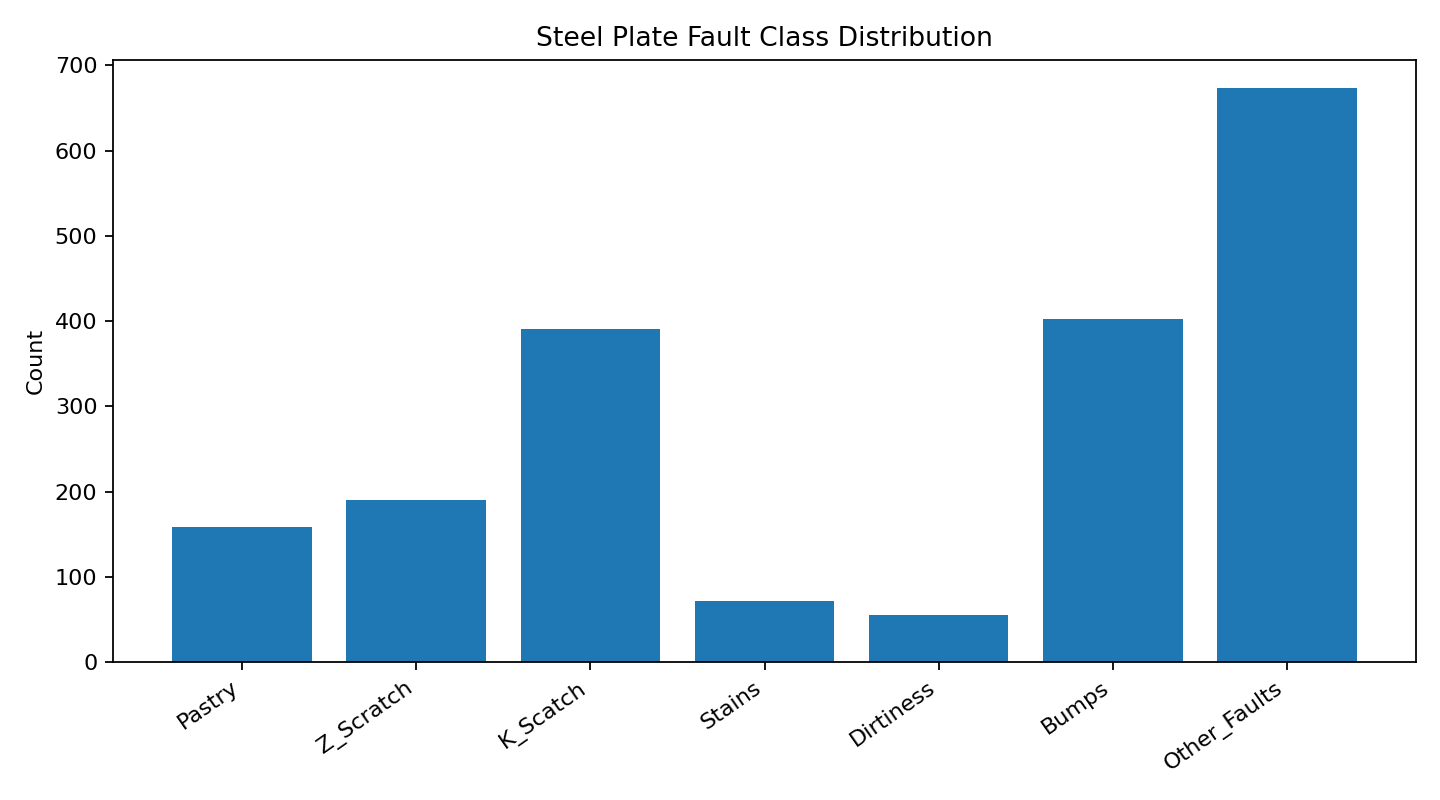

FIGURE: boxplot_by_class.png


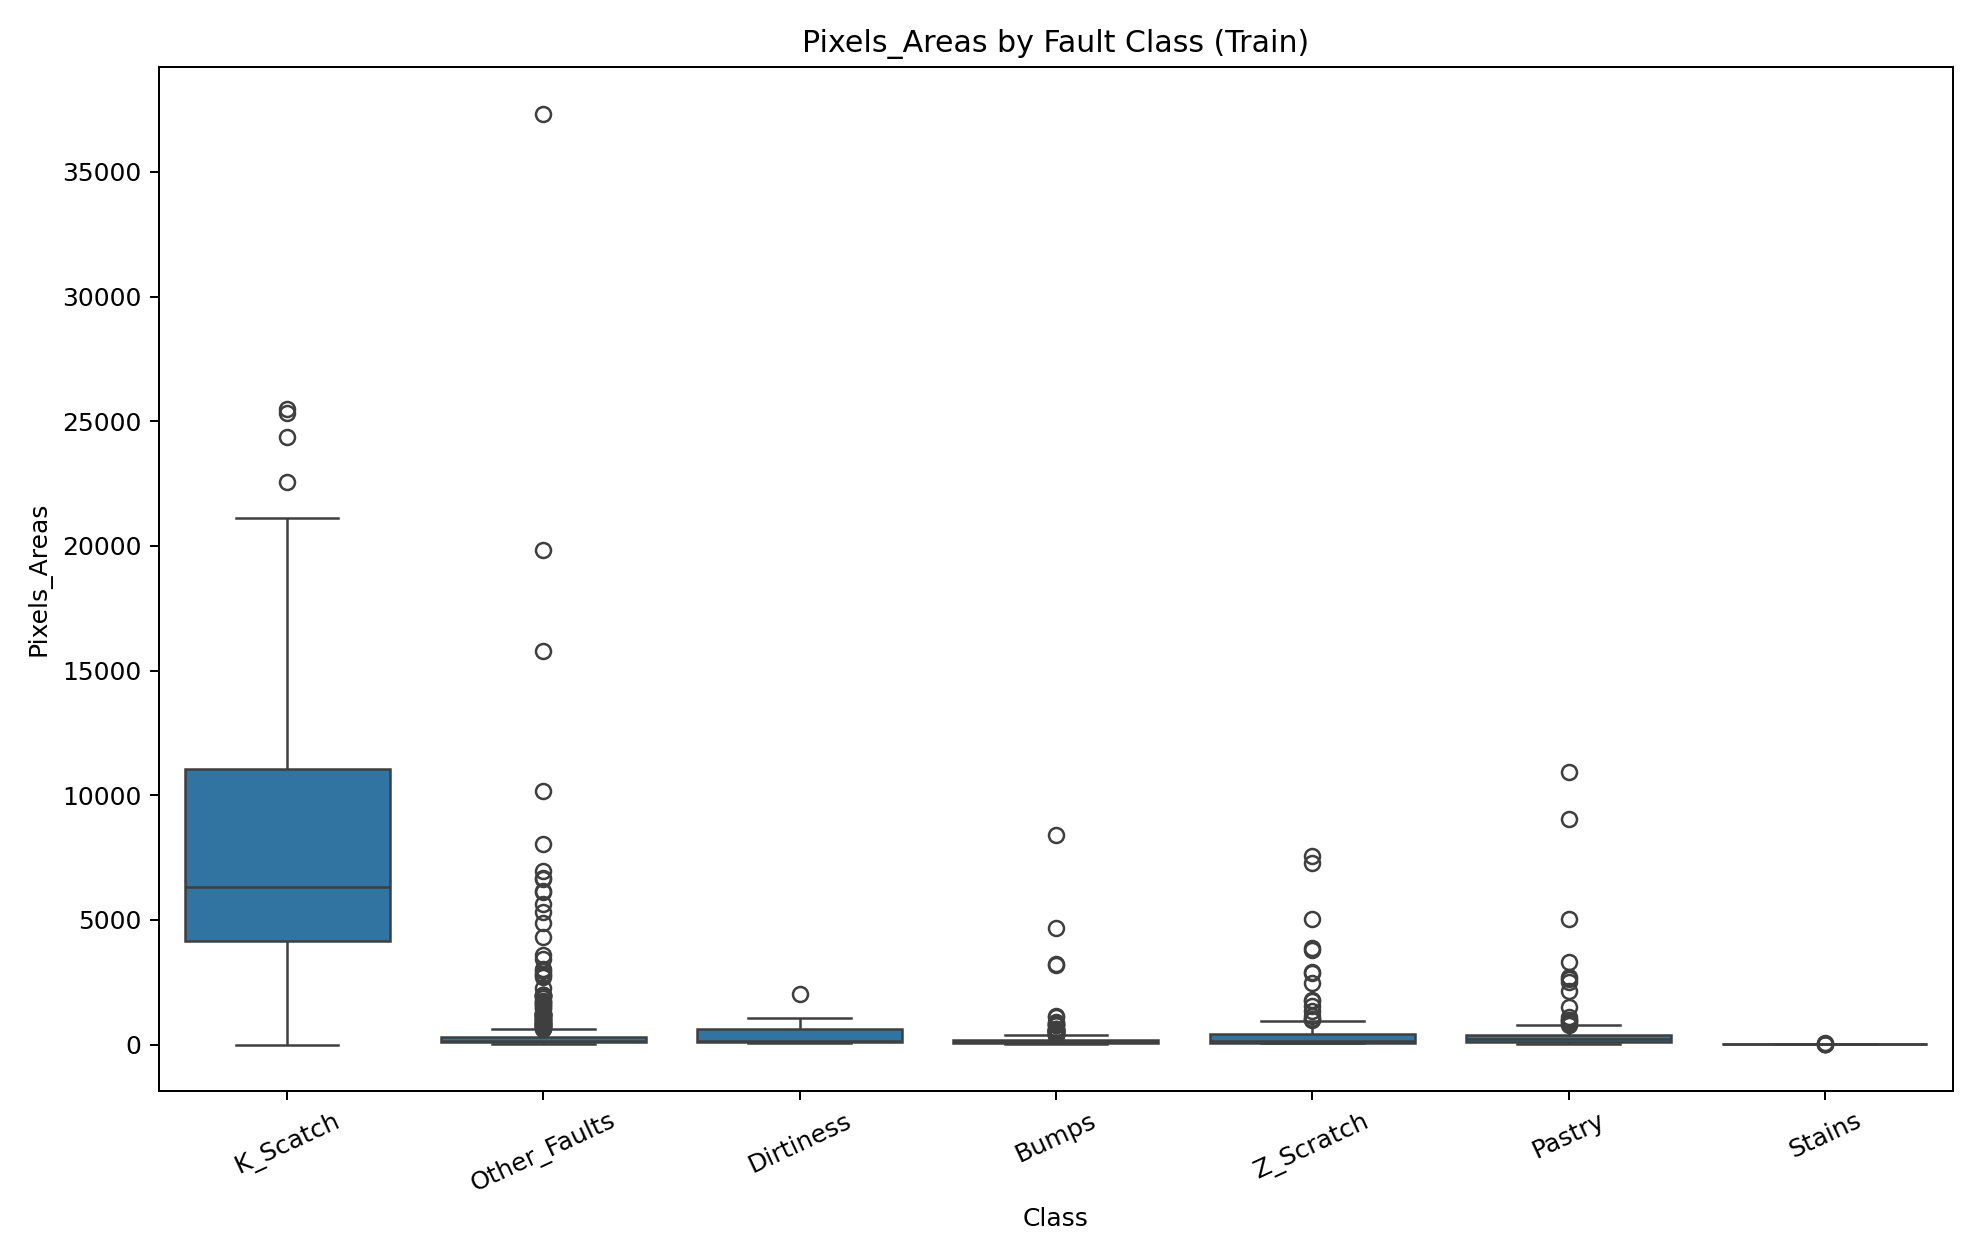

FIGURE: scatter_plot_1.png


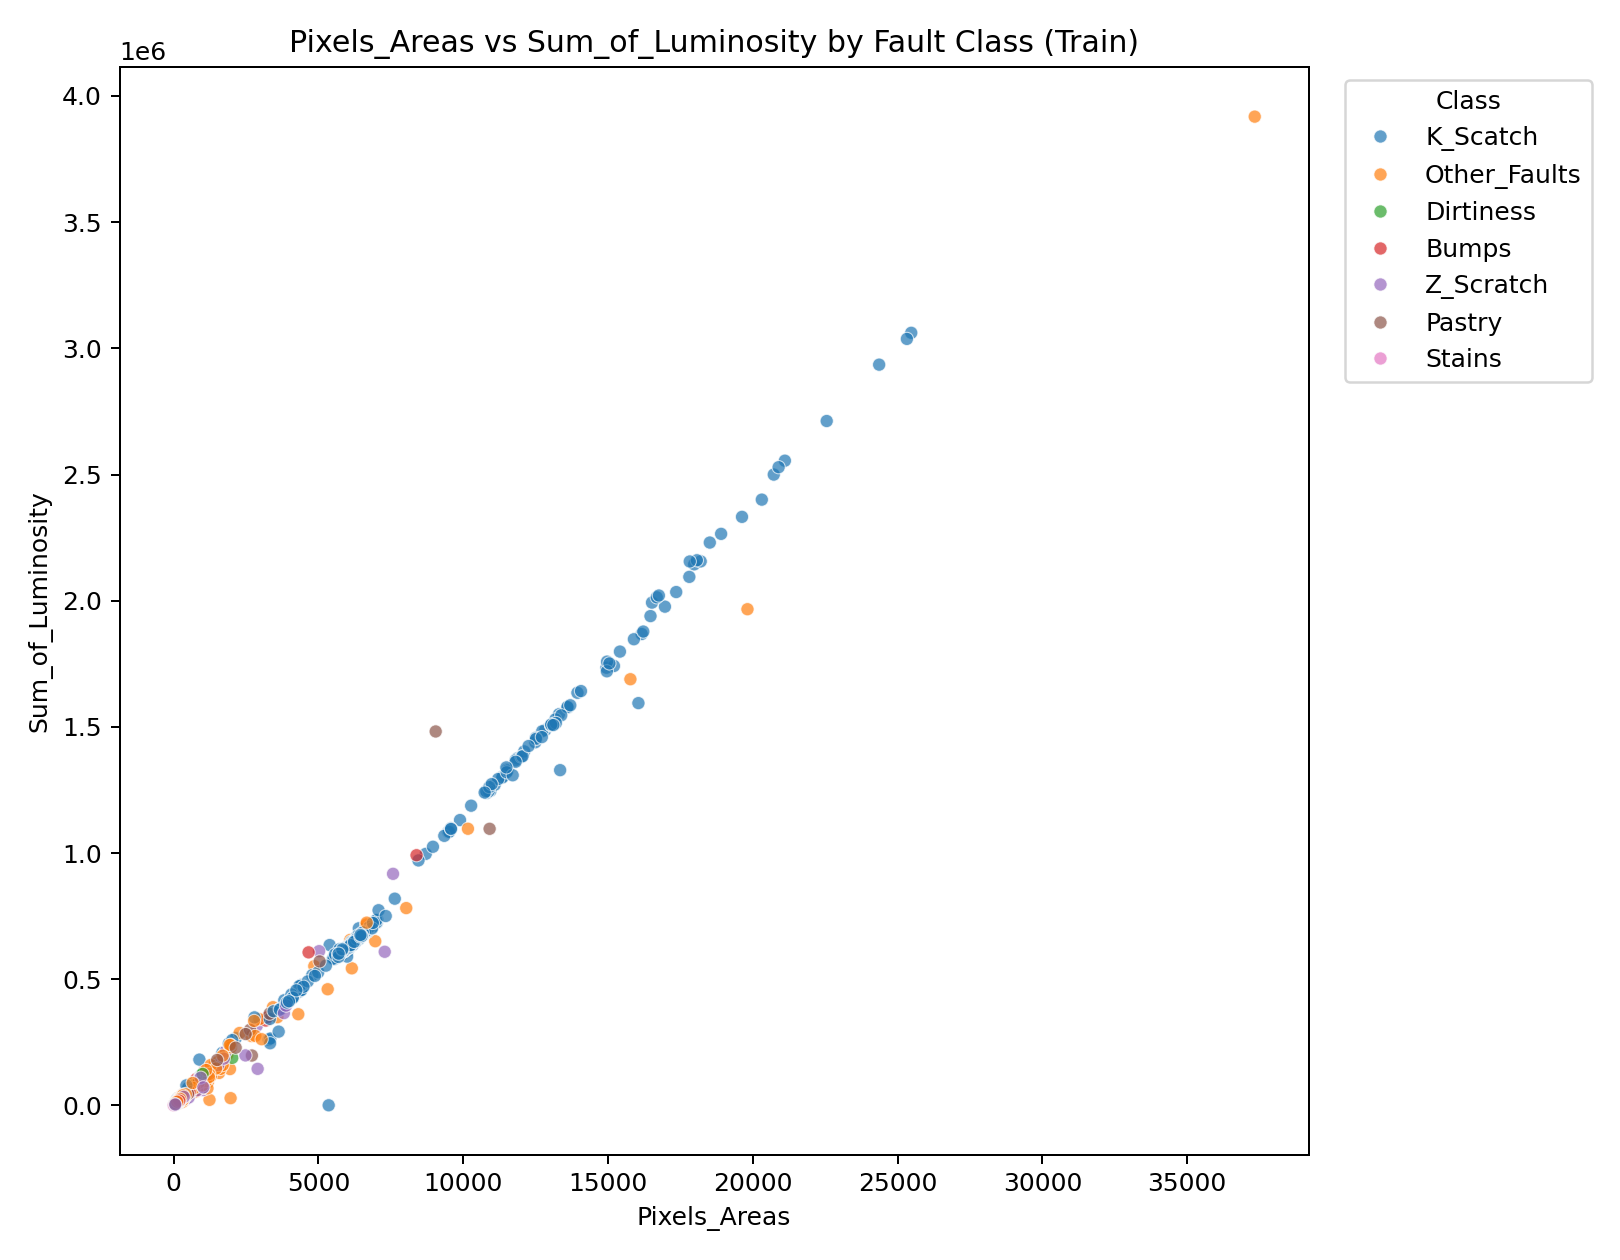

FIGURE: scatter_plot_2.png


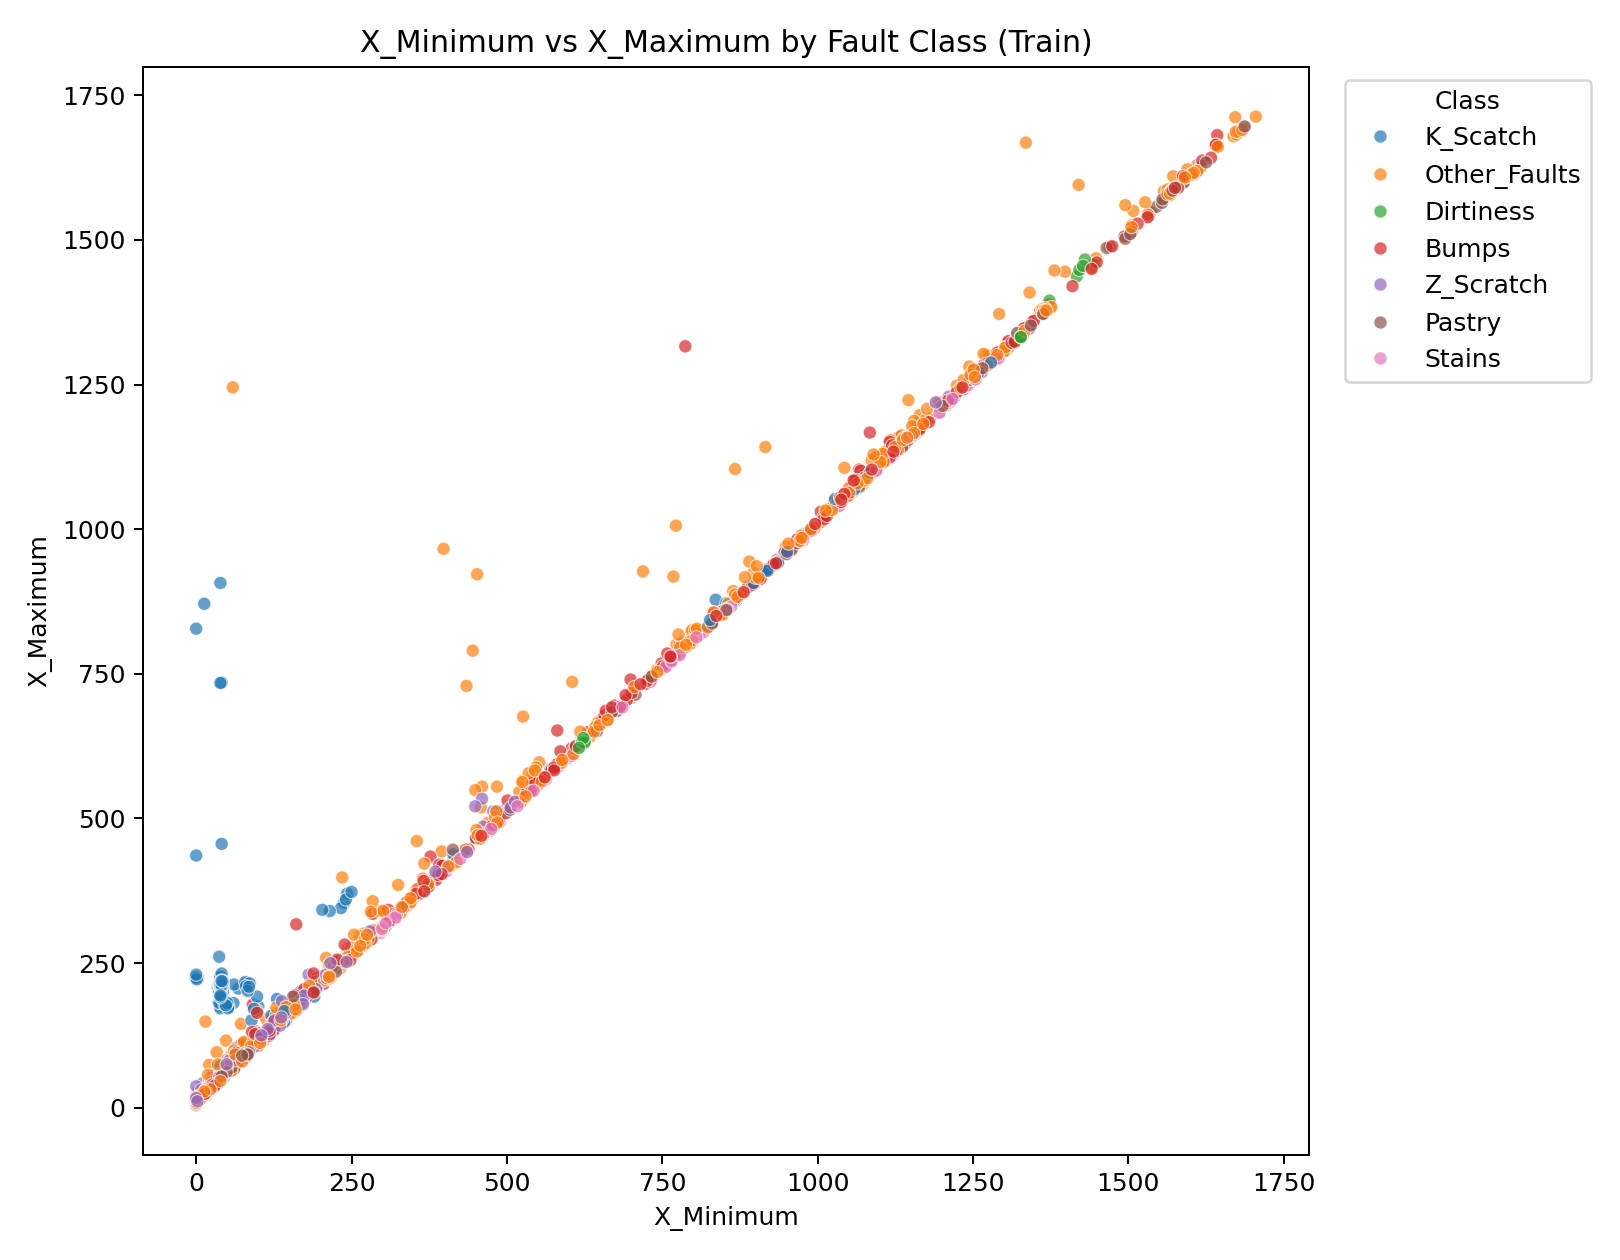

FIGURE: correlation_matrix.png


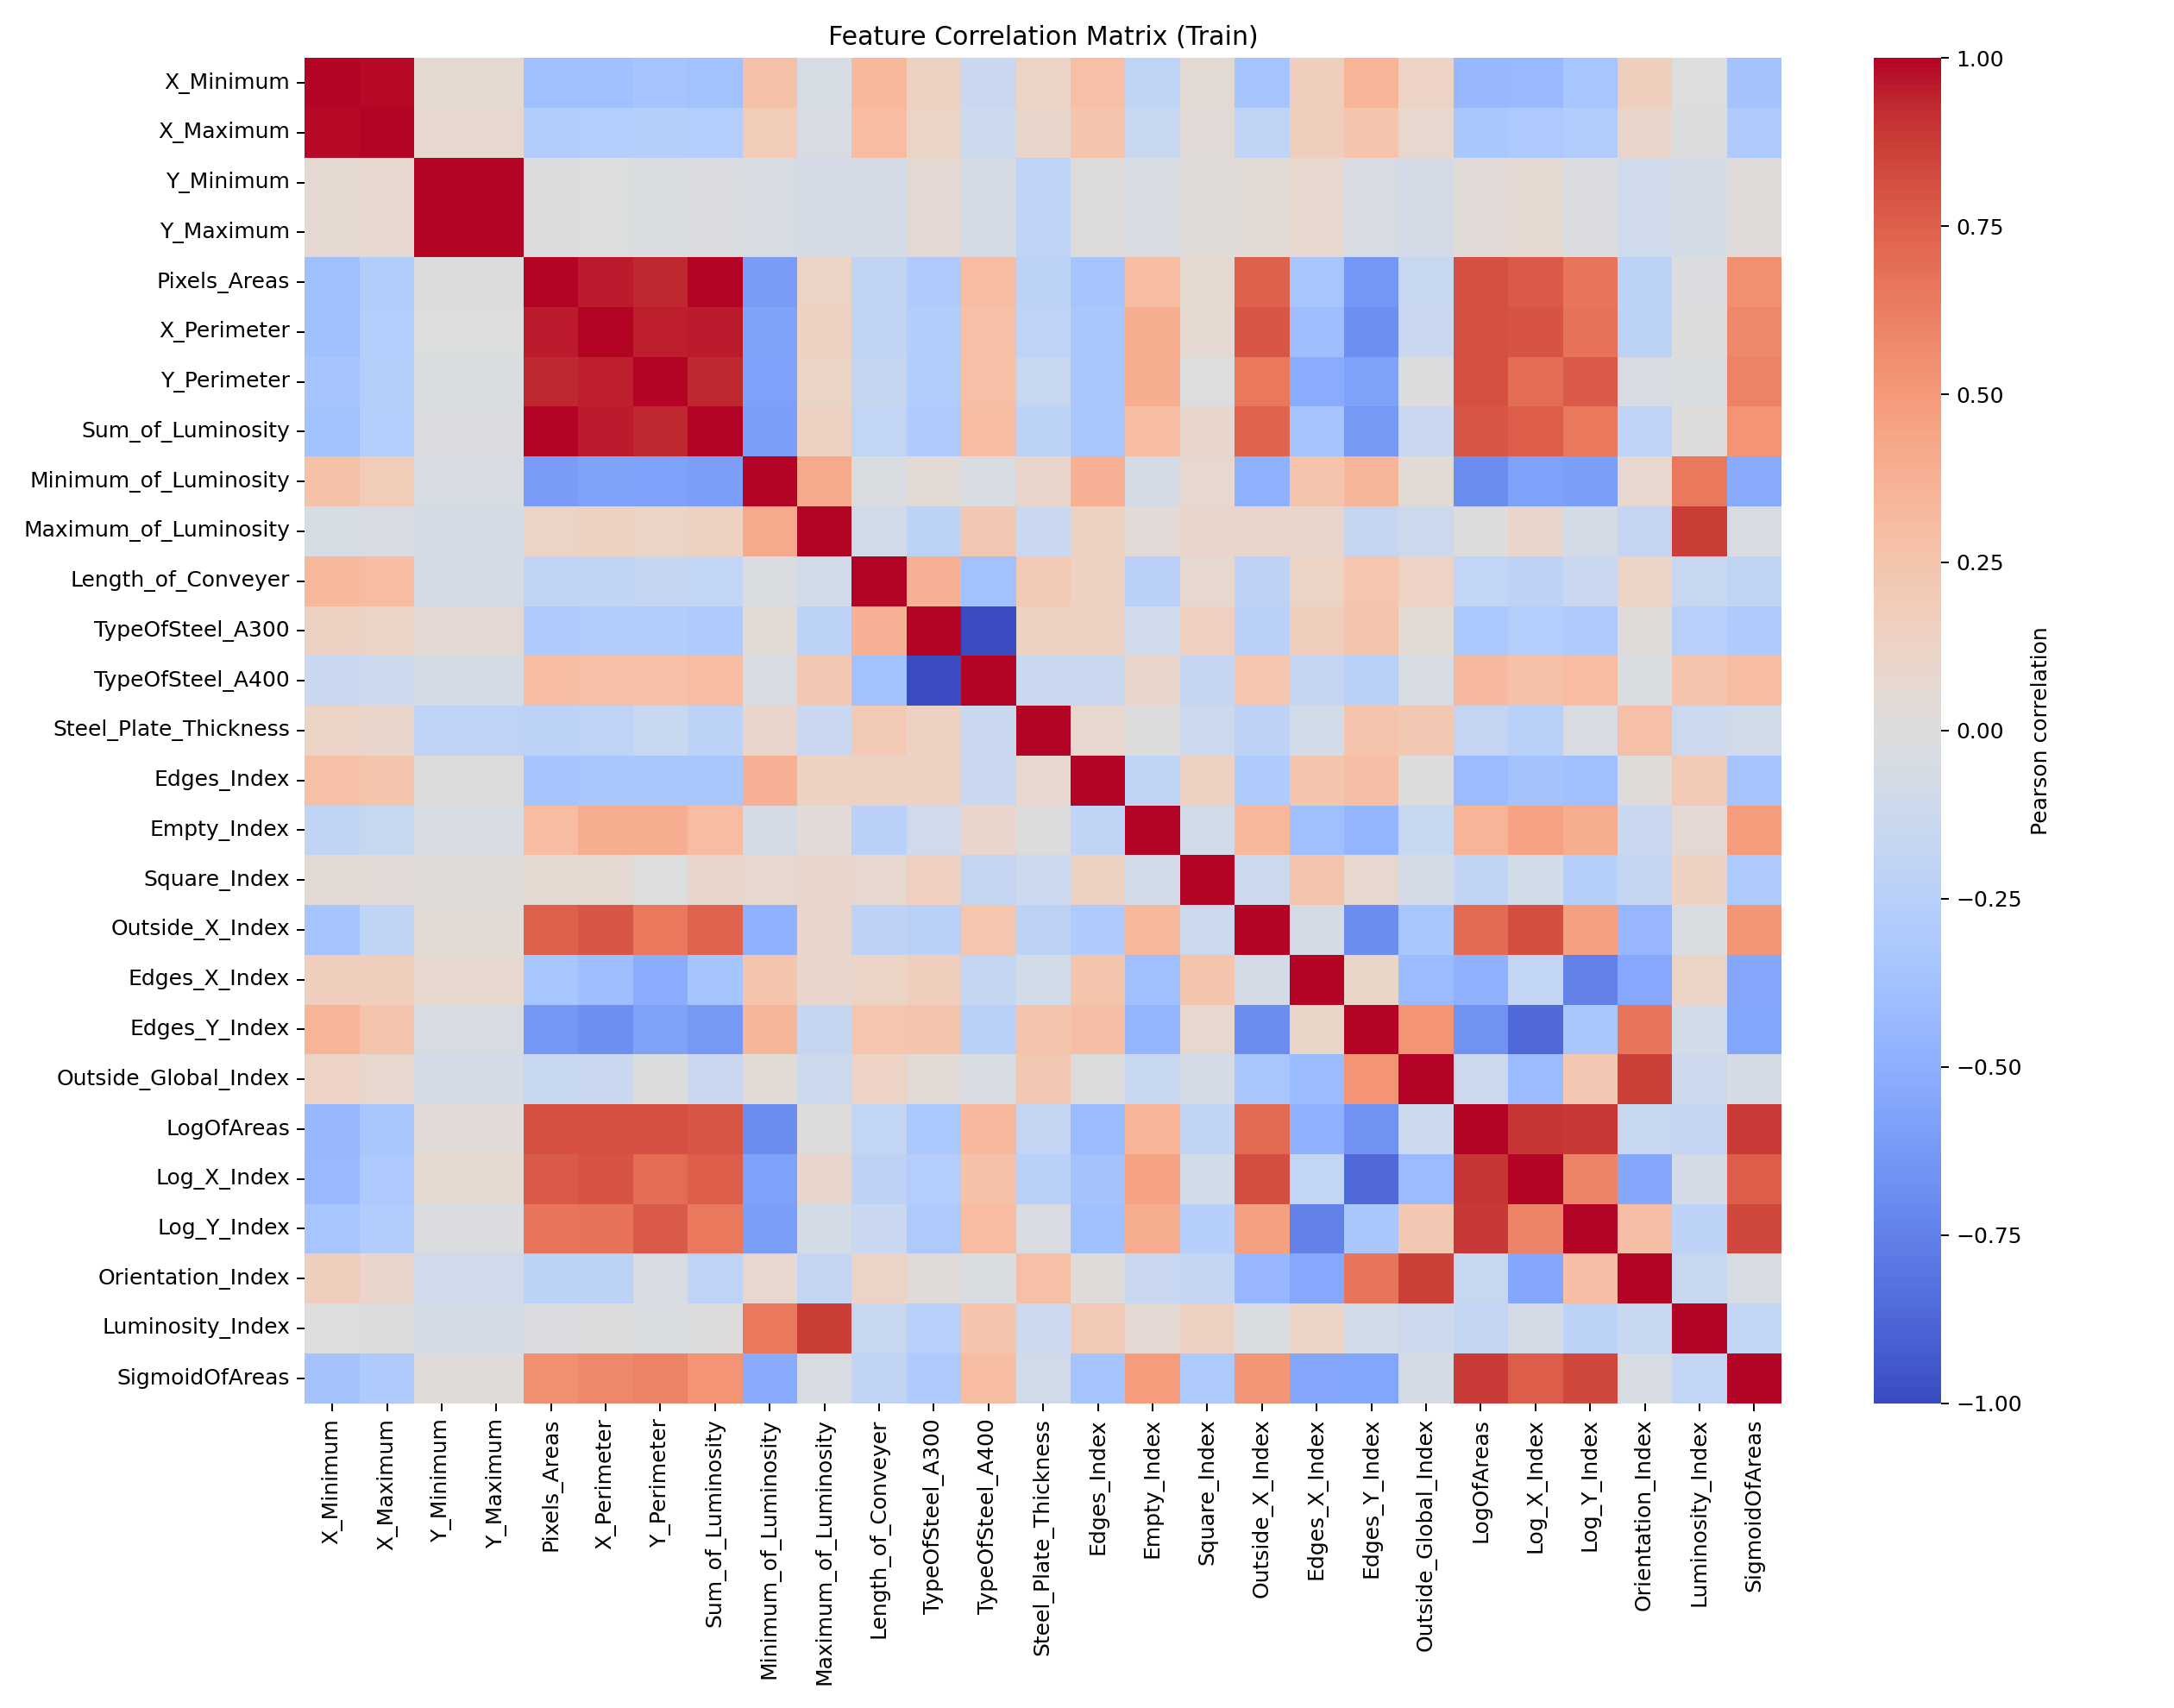

FIGURE: feature_distributions.png


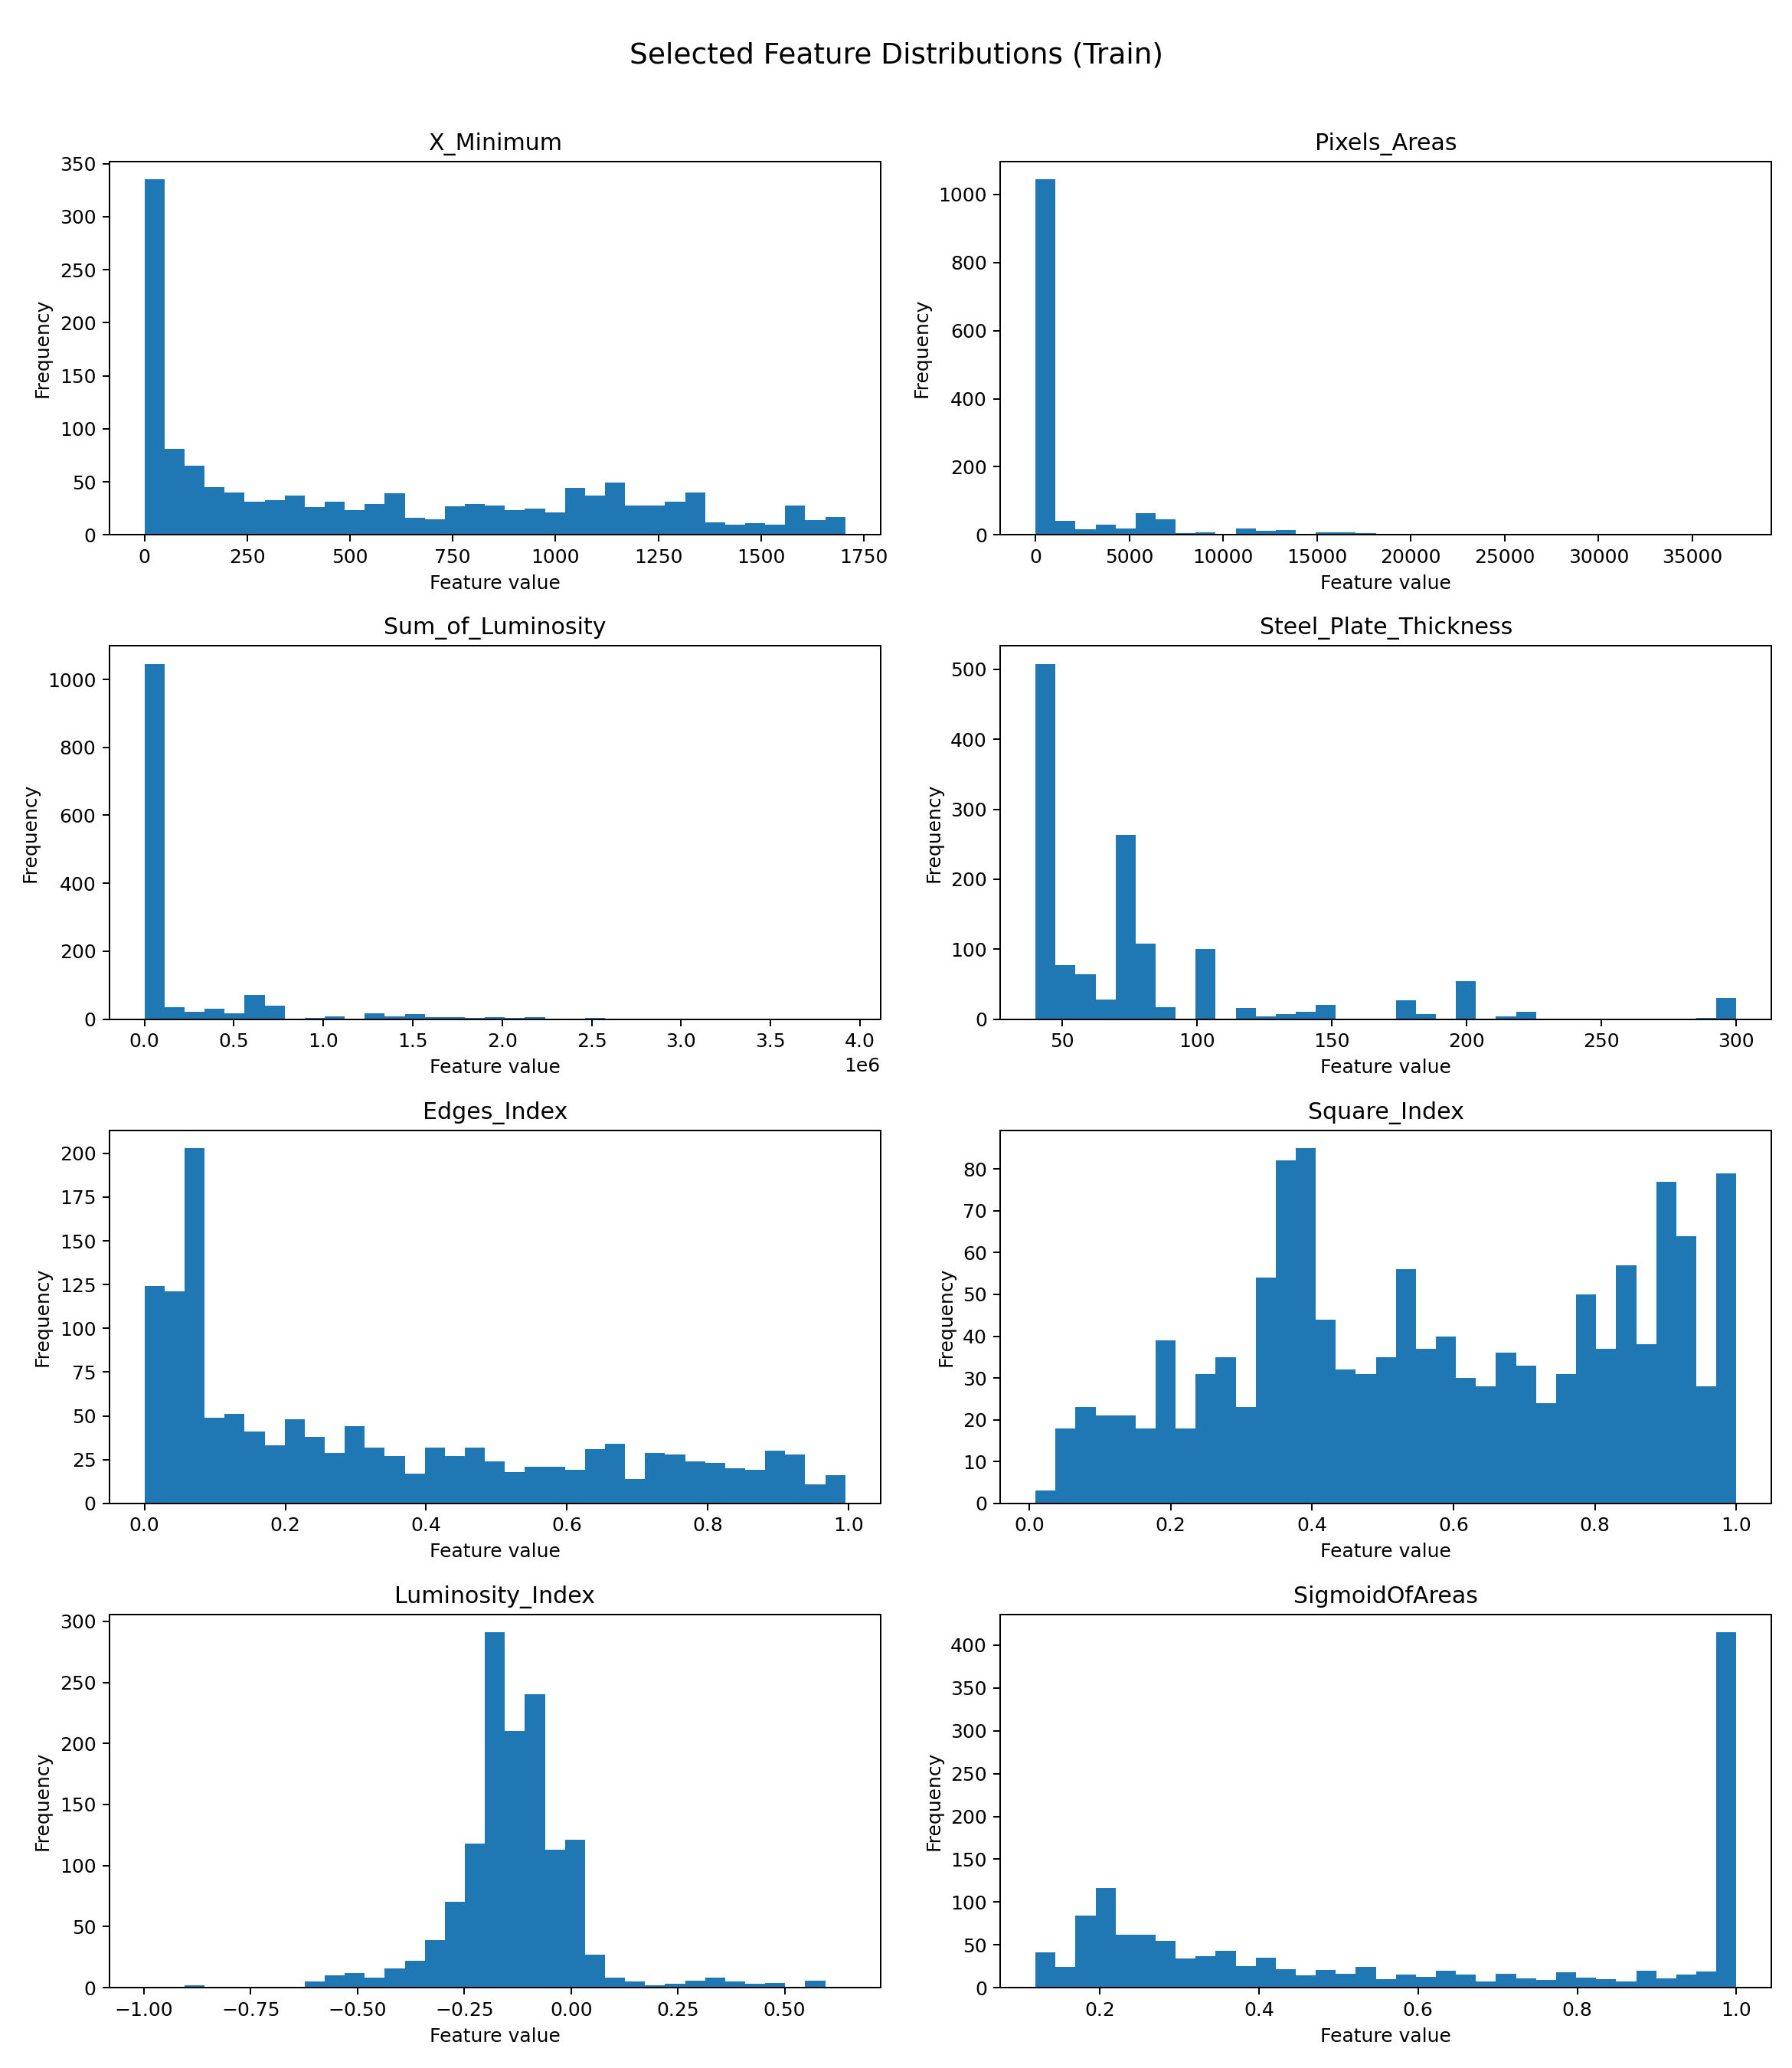

FIGURE: ga_convergence.png


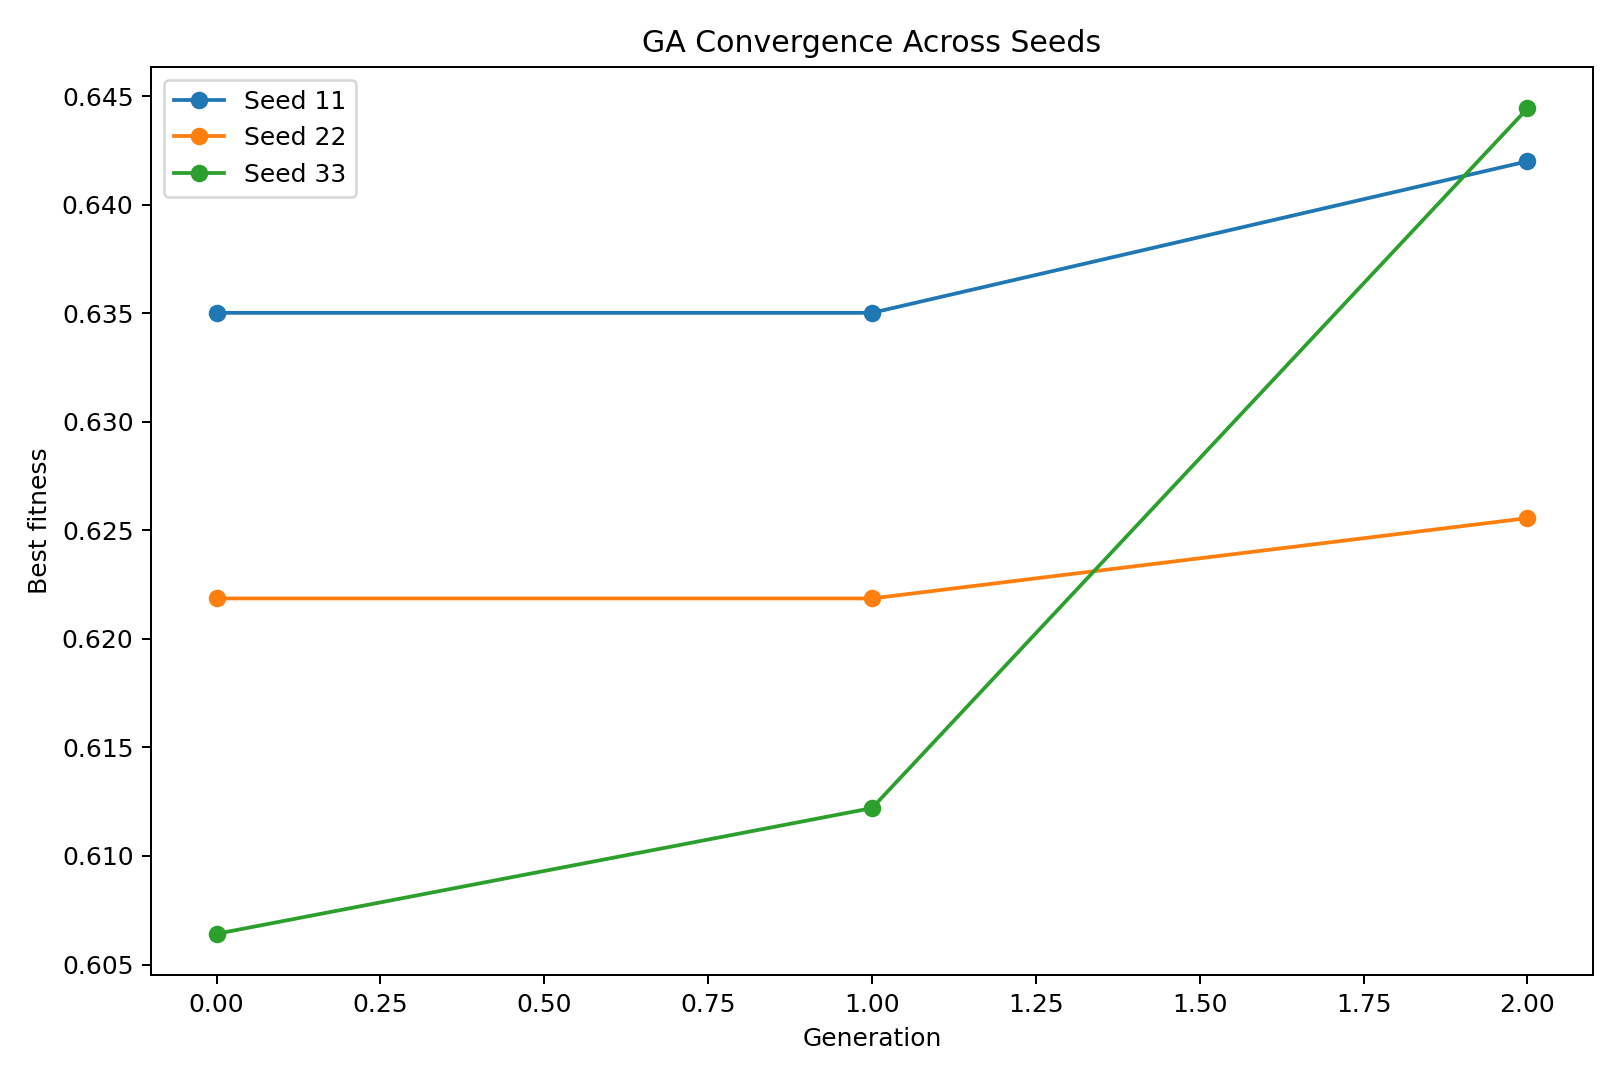

FIGURE: ga_feature_frequency.png


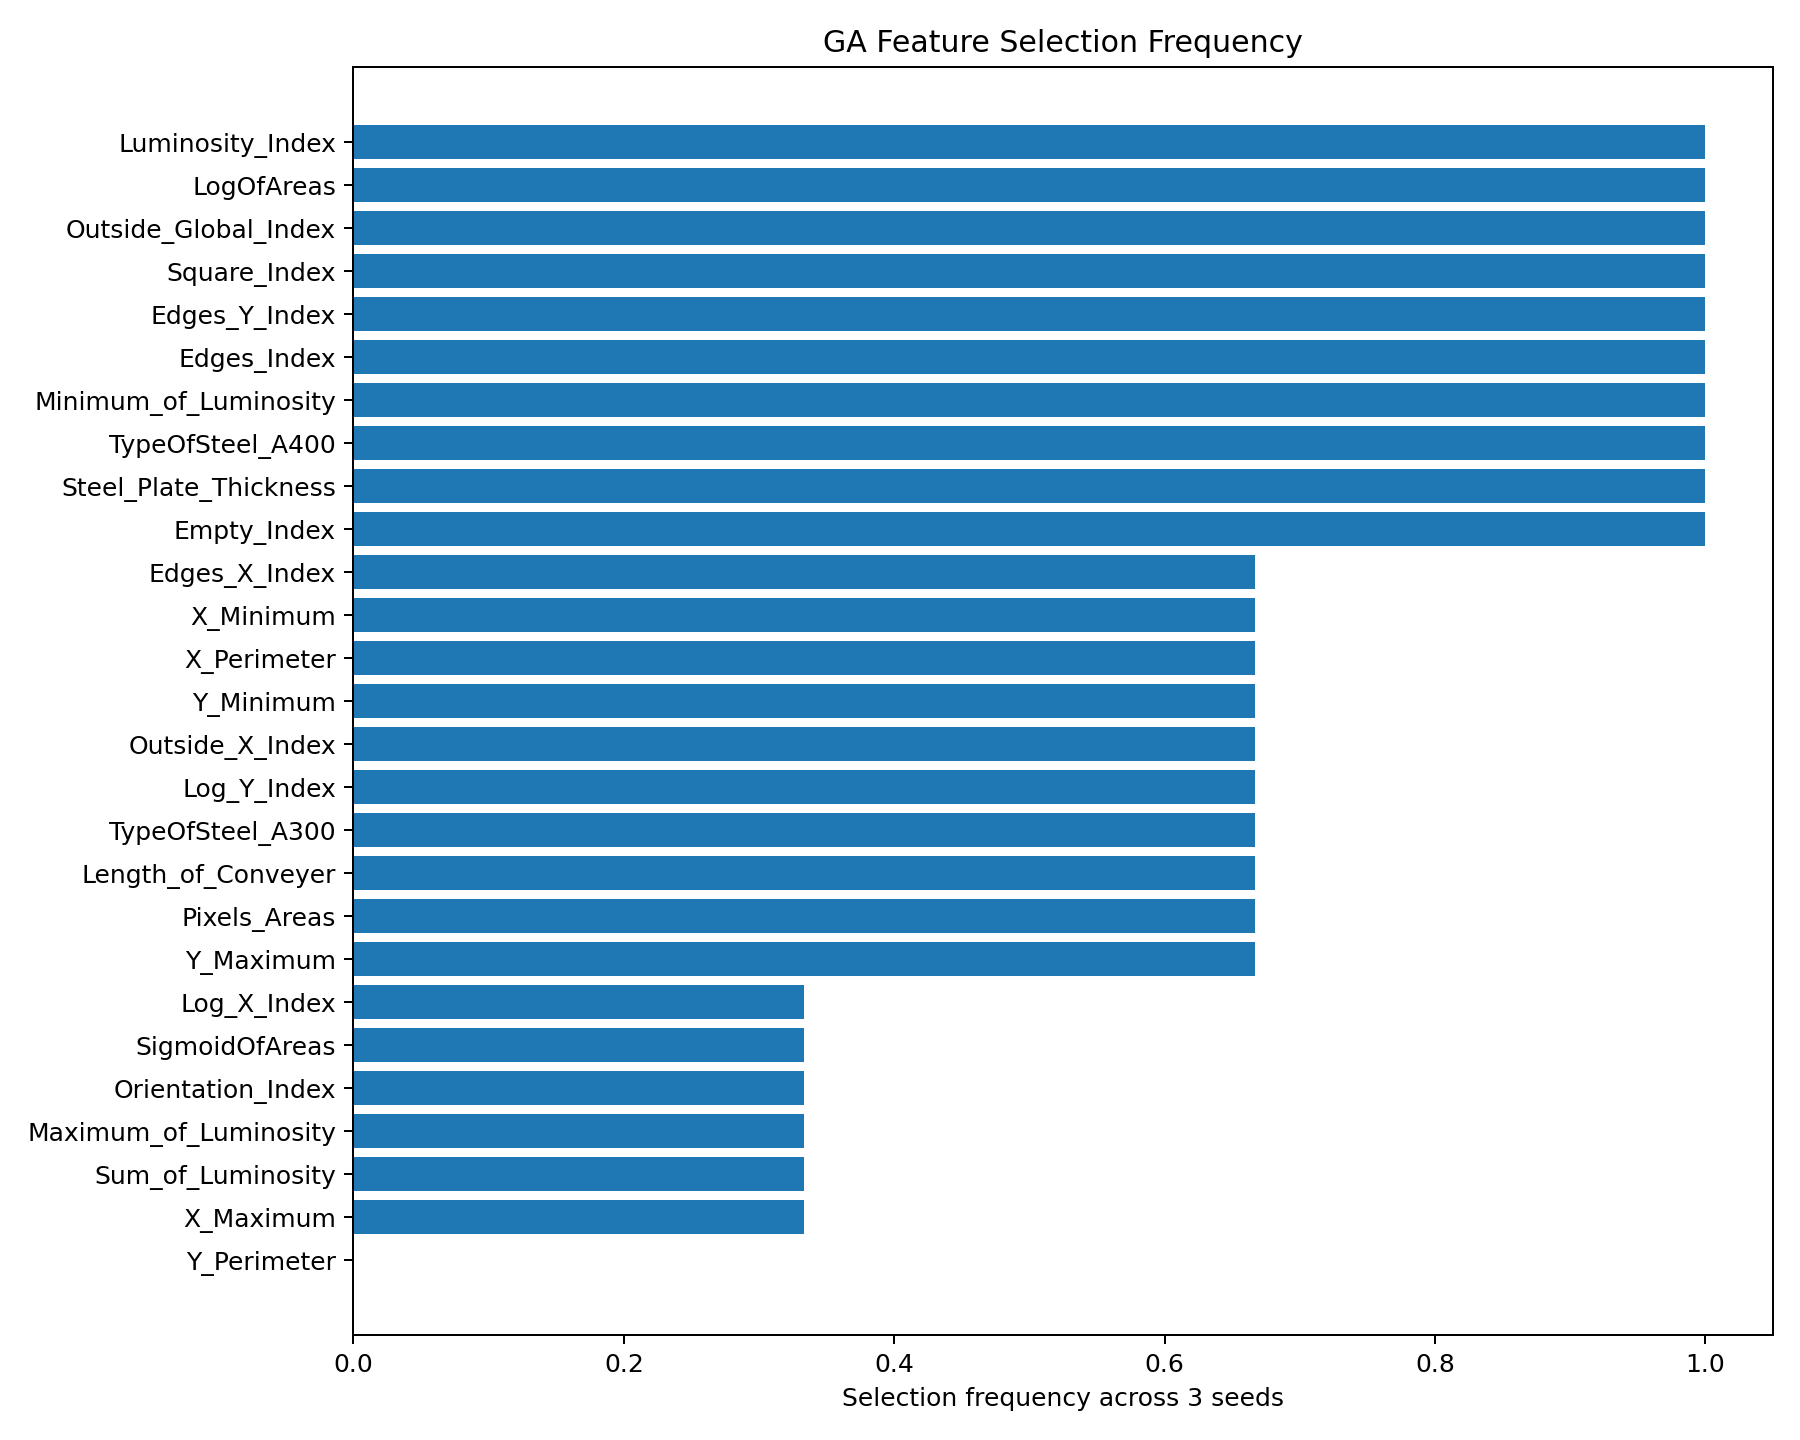

FIGURE: confusion_matrix.png


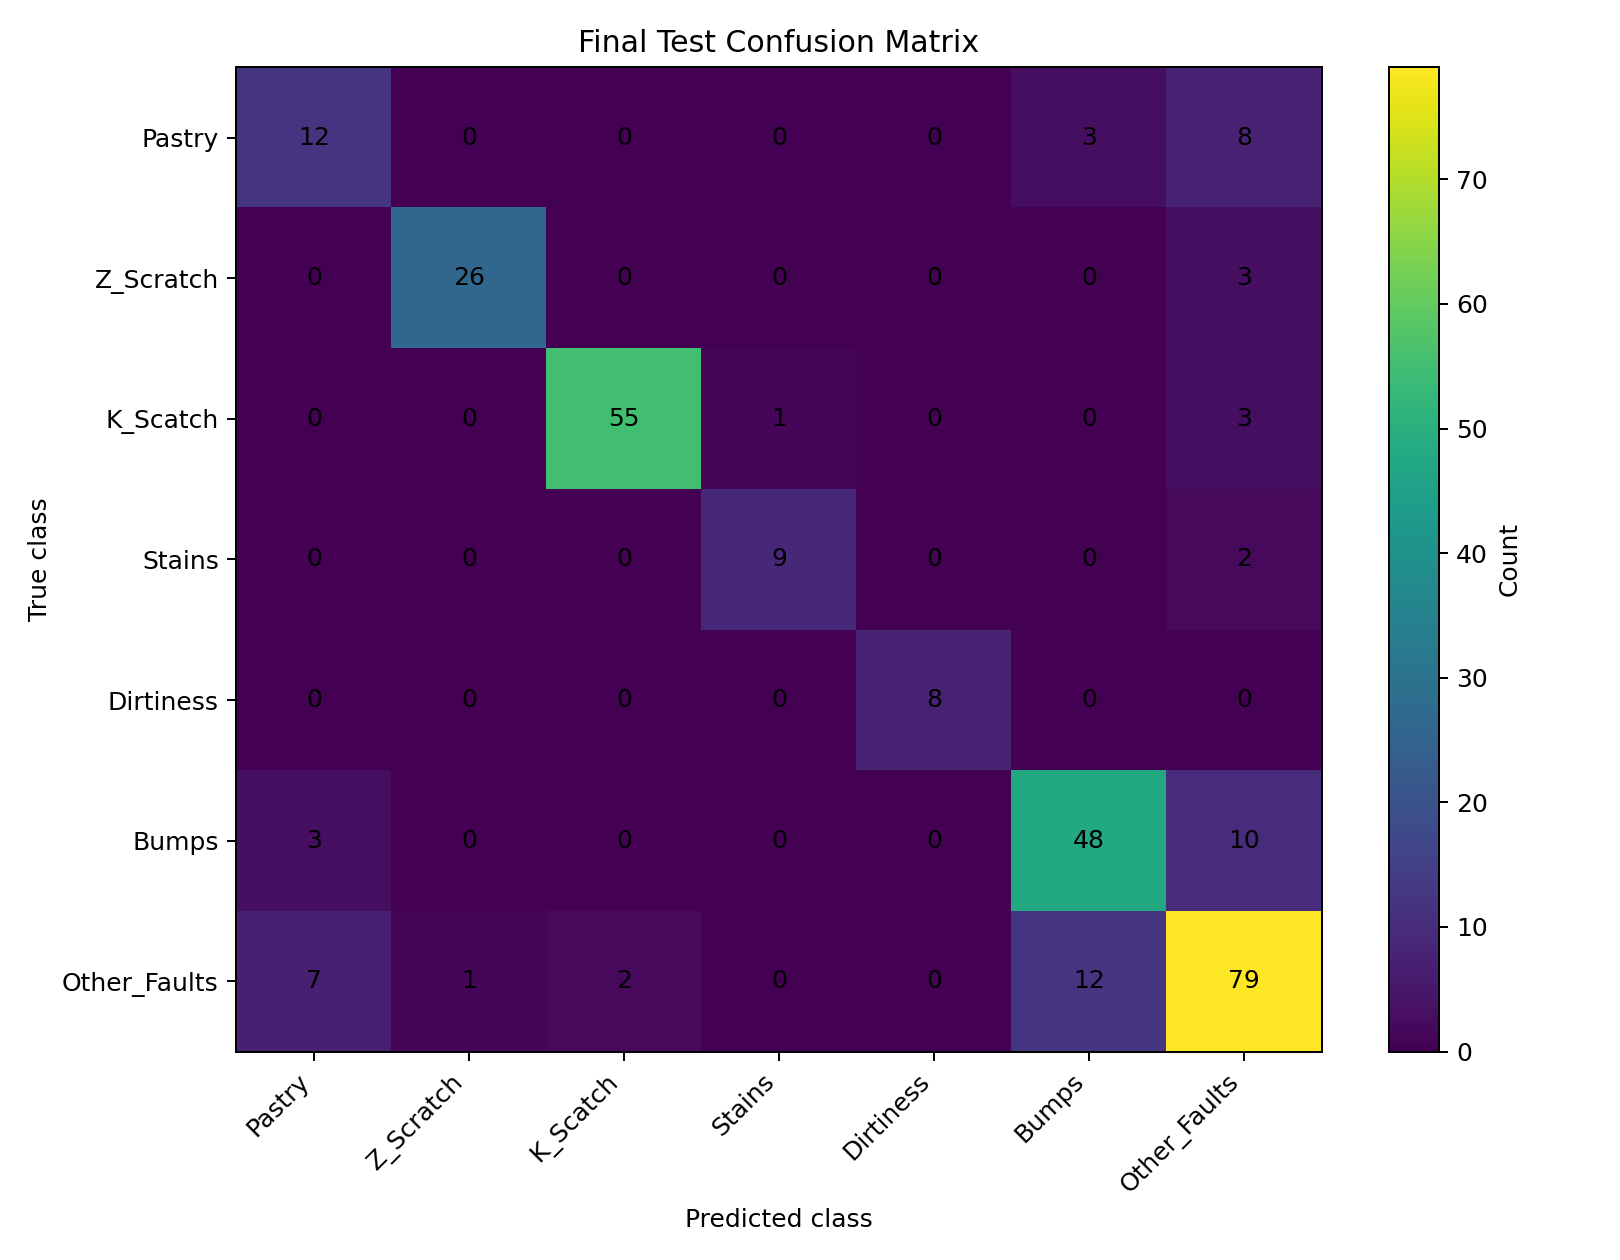

FIGURE: outlier_analysis.png


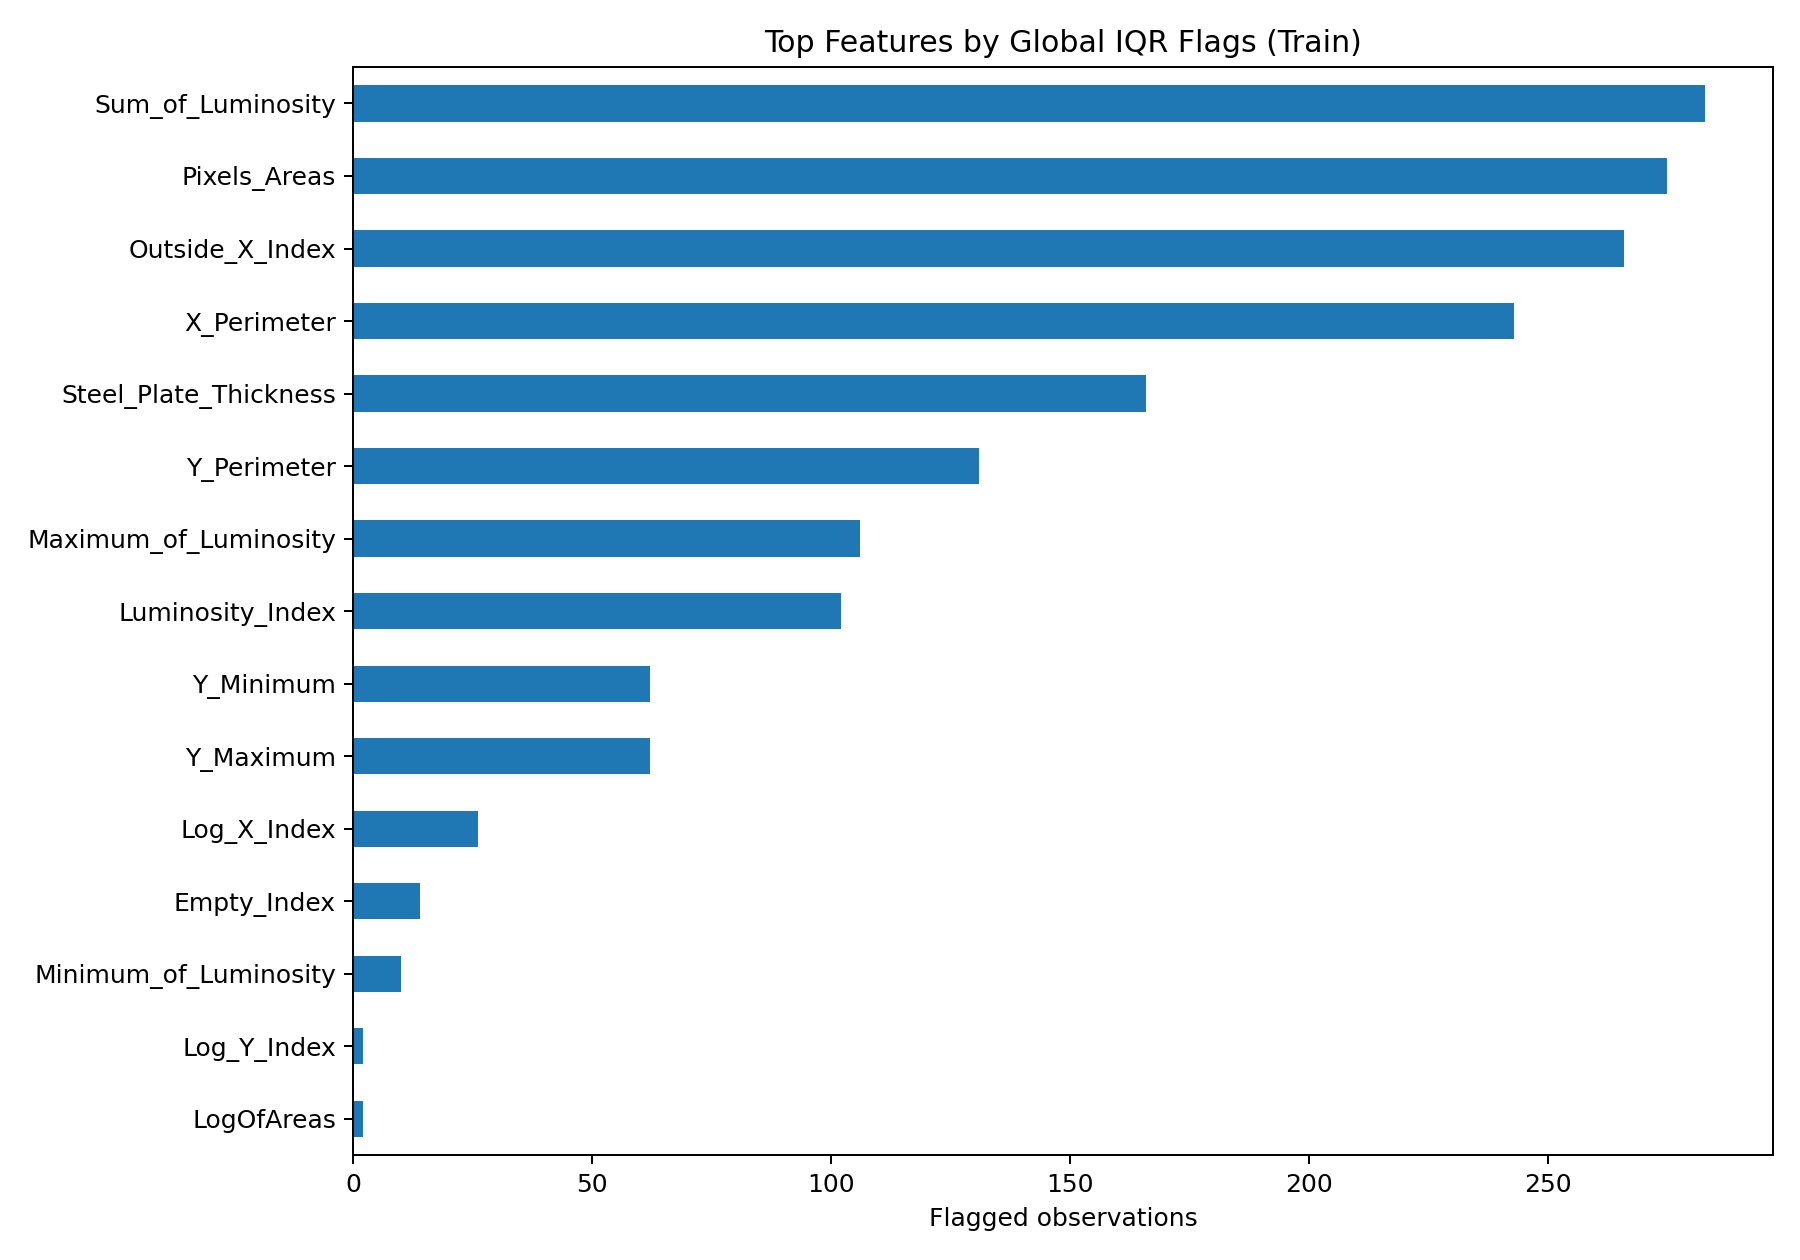

noise sensitivity:


,model,candidate,feature_subset,feature_count,n_features,evaluation_split,noise_level,noise_definition,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,precision_Pastry,recall_Pastry,f1_Pastry,precision_Z_Scratch,recall_Z_Scratch,f1_Z_Scratch,precision_K_Scatch,recall_K_Scatch,f1_K_Scatch,precision_Stains,recall_Stains,f1_Stains,precision_Dirtiness,recall_Dirtiness,f1_Dirtiness,precision_Bumps,recall_Bumps,f1_Bumps,precision_Other_Faults,recall_Other_Faults,f1_Other_Faults
0,RandomForest_Nonlinear,All_27,All_27,27,27,Validation,0.00,Gaussian perturbation on continuous selected f...,0.783505,0.802609,0.828847,0.784538,0.862837,0.802609,0.72,0.750000,0.734694,1.000000,0.892857,0.943396,0.981132,0.896552,0.936937,1.000000,0.818182,0.900000,1.0,0.888889,0.941176,0.647059,0.550000,0.594595,0.691667,0.821782,0.751131
1,RandomForest_Nonlinear,All_27,All_27,27,27,Validation,0.01,Gaussian perturbation on continuous selected f...,0.776632,0.774491,0.803050,0.778453,0.840839,0.774491,0.64,0.666667,0.653061,1.000000,0.857143,0.923077,0.981132,0.896552,0.936937,0.900000,0.818182,0.857143,1.0,0.777778,0.875000,0.673077,0.583333,0.625000,0.691667,0.821782,0.751131
2,RandomForest_Nonlinear,All_27,All_27,27,27,Validation,0.05,Gaussian perturbation on continuous selected f...,0.725086,0.701815,0.744981,0.723925,0.810936,0.701815,0.70,0.583333,0.636364,0.900000,0.642857,0.750000,0.962963,0.896552,0.928571,0.900000,0.818182,0.857143,1.0,0.666667,0.800000,0.580000,0.483333,0.527273,0.633588,0.821782,0.715517
3,RandomForest_Nonlinear,All_27,All_27,27,27,Validation,0.10,Gaussian perturbation on continuous selected f...,0.704467,0.670942,0.714500,0.698658,0.803024,0.670942,0.70,0.583333,0.636364,0.928571,0.464286,0.619048,0.962264,0.879310,0.918919,0.818182,0.818182,0.818182,1.0,0.666667,0.800000,0.619048,0.433333,0.509804,0.593103,0.851485,0.699187


cost-sensitive classes:


,class,operational_assumption,cost_priority_assumption,test_support,recall,false_negatives,selection_impact
0,Stains,"For inspection prioritization, a missed defect...",high,11,0.818182,2,none
1,Dirtiness,"For inspection prioritization, a missed defect...",high,8,1.000000,0,none


GA stability:


,seed_a,seed_b,intersection,union,jaccard
0,11,22,12,25,0.480000
1,11,33,14,24,0.583333
2,22,33,14,23,0.608696


In [6]:
from pathlib import Path
import pandas as pd, json
from IPython.display import display, Image
print('Final artifact checks:')
print('processed:', pd.read_csv(ROOT/'data/processed/processed_dataset.csv').shape)
print('classes:')
print(pd.read_csv(ROOT/'results/class_distribution.csv').to_string(index=False))
print('model selection:')
print(pd.read_csv(ROOT/'results/unified_model_selection_validation.csv').to_string(index=False))
print('final test:')
print(json.load(open(ROOT/'results/final_test_metrics.json', encoding='utf-8')))
print('GA configuration:')
print(json.load(open(ROOT/'results/ga_configuration.json', encoding='utf-8')))

for name in ['class_distribution.png','boxplot_by_class.png','scatter_plot_1.png','scatter_plot_2.png','correlation_matrix.png','feature_distributions.png','ga_convergence.png','ga_feature_frequency.png','confusion_matrix.png','outlier_analysis.png']:
    print('FIGURE:', name)
    display(Image(filename=str(ROOT/'figures'/name), width=650))

print('noise sensitivity:')
display(pd.read_csv(ROOT/'results/noise_sensitivity.csv'))
print('cost-sensitive classes:')
display(pd.read_csv(ROOT/'results/cost_sensitive_classes.csv'))
print('GA stability:')
display(pd.read_csv(ROOT/'results/ga_subset_overlap.csv'))

## ۶. بازتولیدپذیری و ممیزی نشت داده
تمام تبدیل‌های یادگرفتنی و تصمیم‌های انتخاب ویژگی به Train/CV محدود هستند. مجموعه Test فقط پس از تثبیت انتخاب‌ها برای ارزیابی نهایی استفاده می‌شود. ممیزی رسمی در `results/leakage_audit.md` قرار دارد. اجرای Stageها با `runpy` داخل همان Kernel انجام می‌شود و نمودارهای اصلی نیز در همین Notebook نمایش داده می‌شوند.
